# PS-S06E06: NN - Tabular ResNet (Embeddings)

This notebook tackles the [**Playground Series - Season 6, Episode 7: Predicting Student Health Risk**](https://www.kaggle.com/competitions/playground-series-s6e7), a competition focused on predicting a class label (`at-risk`, `unhealthy`, and `fit`) for the `health_condition` target, based on features describing sleep, heart rate, BMI, physical activity, and other lifestyle behaviors for each student.

**Task**
* Three-class classification: predict **at-risk**, **unhealthy**, or **fit**
* Target column: `health_condition`
* Evaluation metric: **Balanced Accuracy**
* Submission format: hard class label per row

**Model**
* Tabular neural network with:
    * Numeric features (BMI, sleep duration, step count, active hours, stress levels, etc.)
    * Embedded categorical features (`stress_level`, `sleep_quality`, `smoking_alcohol`, `gender`, `physical_activity_level`)
    * Residual MLP backbone
* Trained using stratified cross-validation
* Final predictions are averaged (soft) across folds then decoded to class labels

This notebook is one of a number of notebooks that explore various models to address this challenge. The EDA was performed in: [**PS-S06E07: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e07-eda).

## Import Needed Packages

In [1]:
import os
import gc
import sys
import copy
import math
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e07_feature_engineering import FeatureFactory
from ps_s06e07_model_visualizer import ModelVisualizer
from ps_s06e07_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [2]:
setup = ExperimentSetup(
    model_name='NN Tabular ResNet',
    use_gpu=True,
)

seed = setup.set_seeds()

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    
setup.configure_pandas()
setup.suppress_warnings()

# The target feature
TARGET = 'health_condition'

# Class label mapping - must be consistent everywhere
target_mapping = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}
inverse_target_mapping = {v: k for k, v in target_mapping.items()}
N_CLASSES = 3

setup.describe()

Random seed set to: 10301
Warnings suppressed.

Experiment Setup
Model         : NN Tabular ResNet
Target        : health_condition
Use GPU       : True
RFE           : False
Optuna Tuning : False 
On Kaggle     : False


## Read and Examine the Training Dataset

### Dataset Description
The dataset contains student lifestyle survey responses and behavior indicators.

**Key characteristics**
* Mixed numeric (BMI, step counts, sleep duration, heart rate, active hours, calorie expenditure) and categorical (`stress_level`, `sleep_quality`, `physical_activity_level`, `smoking_alcohol`, `gender`) inputs
* Large dataset (~690k training rows) - well-suited for neural network training
* Target labels are strings: `at-risk`, `unhealthy`, `fit`

**Target encoding**
* `at-risk` &rarr; 0
* `unhealthy` &rarr; 1
* `fit` &rarr; 2

In [3]:
training_df = setup.get_combined_training_data(include_original=False)
train_ids = training_df['id'].copy()

TRAINING DATASET

   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy           5.220      70.600 25.660   
1   1          at-risk           5.530      71.300 25.840   
2   2        unhealthy           5.290      75.400 24.540   
3   3        unhealthy           4.700      77.200 23.130   
4   4          at-risk           7.230      73.400 28.440   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0            2,174.000   1,326.000             19.800         1.860       veg   
1            1,966.000   9,891.000             49.900         1.260   non-veg   
2            2,688.000  14,216.000             38.100         1.600       veg   
3            2,630.000   7,174.000             59.900         2.020       veg   
4            2,560.000   6,584.000             46.000         2.250       veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol  gender  \
0         high       average               seden

## Read and Examine the Test Dataset

In [4]:
test_df = setup.read_dataset('test')
test_ids  = test_df['id'].copy()

TEST DATASET

       id  sleep_duration  heart_rate    bmi  calorie_expenditure  step_count  \
0  690088           5.350      64.900 23.480            2,745.000  14,167.000   
1  690089             NaN      83.100 22.420            1,773.000   6,801.000   
2  690090           6.680      59.700 24.140            3,040.000  13,250.000   
3  690091           7.130      78.500 26.260            2,494.000   6,331.000   
4  690092           5.490      77.700 23.290            1,828.000  13,894.000   

   exercise_duration  water_intake diet_type stress_level sleep_quality  \
0             59.500         1.860       veg         high          poor   
1             24.500         2.400  balanced         high          poor   
2             48.500         2.760  balanced       medium          poor   
3             56.900         2.340       veg          low          good   
4             39.400         2.450       veg         high       average   

  physical_activity_level smoking_alcohol gender

## Feature Engineering Strategy
Feature engineering is intentionally conservative to preserve signal for the neural network.

### Applied strategies
* **`encoding`** - Casts categorical features (like `stress_level`, `sleep_quality`, `smoking_alcohol`, `gender`) to `category` dtype so the encoder can build embedding tables for them
* **`sleep_stress`** - Sleep duration and quality metrics interacting with stress levels
* **`activity_energy`** - Step counts, exercise duration, and calorie expenditure interaction ratios
* **`bmi_features`** - Body Mass Index indicators and category mappings
* **`risk_score`** - Calculated composite health risk index based on unhealthy behavior combinations
* **`missing_flags`** - Explicit boolean indicator flags for missing values in survey columns

### Not applied
* **`interactions`** & **`numeric_expansion`** - Higher-order cross-products and math expansions are omitted; the residual network can learn these internally
* **Standard scaling** - Applied inside the training loop per-fold to prevent leakage, not in the FeatureFactory

### Categorical handling
* Categorical features are passed as integer codes to embedding layers. Embeddings are learned directly by the network - no one-hot encoding needed.

In [5]:
fe_strategies = [
    'encoding',
    'sleep_stress',
    'activity_energy',
    'bmi_features',
    'risk_score',
    'missing_flags',
    'numeric_expansion',
]

In [6]:
print('Performing initial feature engineering.')

# Encode target: at-risk=0, unhealthy=1, fit=2
y = training_df[TARGET].map(target_mapping).astype(np.int64).values

feature_engineer = FeatureFactory(
    strategies=fe_strategies,
    target=TARGET,
    seed=seed
)

X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

cat_features = feature_engineer.get_cat_features(X)
print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(f'Cat features for NN embeddings ({len(cat_features)}): {cat_features}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 15
New Feature Count: 59
Cat features for NN embeddings (7): ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'bmi_category']
   sleep_duration  heart_rate    bmi  calorie_expenditure  step_count  \
0           5.220      70.600 25.660            2,174.000   1,326.000   
1           5.530      71.300 25.840            1,966.000   9,891.000   
2           5.290      75.400 24.540            2,688.000  14,216.000   
3           4.700      77.200 23.130            2,630.000   7,174.000   
4           7.230      73.400 28.440            2,560.000   6,584.000   

   exercise_duration  water_intake diet_type stress_level sleep_quality  \
0             19.800         1.860       veg         high       average   
1             49.900         1.260   non-veg          low       average   
2             38.100         1.600       veg         high          poor   
3             59.900  

### Model Training: Neural Network Strategy (3-Class Classification)

Model training is performed using **5-Fold Stratified Cross-Validation**.

1. **Feature Scaling and Input Preparation**
   * Numeric features are standardized per-fold to prevent leakage.
   * Categorical features (like `stress_level`, `sleep_quality`, `smoking_alcohol`, `gender`) are integer-encoded and passed to embedding layers.
   * Target is encoded as at-risk=0, unhealthy=1, fit=2.

2. **Stratified Cross-Validation**
   * `StratifiedKFold` preserves class proportions across all three health classes in every fold.
   * Out-of-fold **probability matrices** (N&times;3) are stored for unbiased evaluation and blending.

3. **Optimization Objective**
   * The model is trained using **CrossEntropyLoss** (the standard multi-class objective).
   * The network outputs raw logits of shape `(batch, 3)`; softmax is applied during evaluation.
   * Model performance is evaluated using **Balanced Accuracy**, matching the competition metric.

4. **Adaptive Learning and Early Stopping**
   * **CosineAnnealingWarmRestarts** provides a cyclic LR schedule.
   * **Early stopping** is applied based on validation Balanced Accuracy.
   * Best model weights per fold are restored before inference.

In [7]:
def fit_nn_encoders(X_train: pd.DataFrame, X_ref: pd.DataFrame, cat_cols: list):
    """
    Fit categorical mappings using X_train + X_ref (usually X_test) so test categories are known.
    Return mappings and numeric column list.
    """
    X_all = pd.concat([X_train[cat_cols], X_ref[cat_cols]], axis=0, ignore_index=True)

    cat_maps = {}
    cat_dims = []
    for c in cat_cols:
        s = X_all[c].astype(str).fillna("__nan__")
        uniq = pd.Index(s.unique())
        cat_maps[c] = {k: i for i, k in enumerate(uniq)}
        cat_dims.append(len(uniq))

    num_cols = [c for c in X_train.columns if c not in cat_cols]
    return {"cat_cols": cat_cols, "num_cols": num_cols, "cat_maps": cat_maps, "cat_dims": cat_dims}


def transform_with_encoders(X: pd.DataFrame, fitted):
    cat_cols = fitted["cat_cols"]
    num_cols = fitted["num_cols"]
    cat_maps = fitted["cat_maps"]

    X_num = X[num_cols].to_numpy(dtype=np.float32)

    X_cat = np.zeros((len(X), len(cat_cols)), dtype=np.int64)
    for j, c in enumerate(cat_cols):
        m = cat_maps[c]
        s = X[c].astype(str).fillna("__nan__")
        X_cat[:, j] = s.map(lambda v: m.get(v, 0)).to_numpy(dtype=np.int64)

    return X_num, X_cat

In [8]:
class ResNetBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super(ResNetBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, input_dim),
            nn.BatchNorm1d(input_dim)
        )
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.block(x))


class TabularResNet(nn.Module):
    def __init__(self, num_dim, cat_dims, n_classes=3, hidden_dim=256, dropout_rate=0.2, num_blocks=4):
        super(TabularResNet, self).__init__()

        # Embedding layers for categoricals
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_cats, emb_dim)
            for num_cats, emb_dim in cat_dims
        ])

        total_cat_dim = sum(emb_dim for _, emb_dim in cat_dims)
        combined_dim = num_dim + total_cat_dim

        self.input_layer = nn.Linear(combined_dim, hidden_dim)
        self.bn0 = nn.BatchNorm1d(hidden_dim)

        self.blocks = nn.ModuleList([
            ResNetBlock(hidden_dim, hidden_dim, dropout_rate)
            for _ in range(num_blocks)
        ])

        # Output head: n_classes logits (was 1 for binary)
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Linear(128, n_classes)   # 3 outputs for at-risk / unhealthy / fit
        )

    def forward(self, x_num, x_cat):
        embedded_cats = [
            emb_layer(x_cat[:, i])
            for i, emb_layer in enumerate(self.embeddings)
        ]
        x = torch.cat(embedded_cats + [x_num], dim=1)
        x = self.input_layer(x)
        x = self.bn0(x)
        for block in self.blocks:
            x = block(x)
        return self.output_head(x)   # raw logits, shape (batch, 3)

In [9]:
class TabularDataset(torch.utils.data.Dataset):
    """Handles dual numeric + categorical inputs for multi-class targets."""
    def __init__(self, x_num, x_cat, y=None):
        self.x_num = torch.FloatTensor(x_num)
        self.x_cat = torch.LongTensor(x_cat)
        # y is class index (int64) for CrossEntropyLoss
        self.y = torch.LongTensor(y) if y is not None else None

    def __len__(self):
        return len(self.x_num)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.x_num[idx], self.x_cat[idx], self.y[idx]
        return self.x_num[idx], self.x_cat[idx]

### Evaluation Metric
**Primary metric: Balanced Accuracy**
* Computed as the arithmetic mean of per-class recall across at-risk, unhealthy, and fit
* Uses **predicted class labels** (argmax of softmax probabilities)
* Matches the Kaggle leaderboard scoring for this competition

**Why Balanced Accuracy**
* Accounts for class imbalance - fit rows outnumber at-risk and unhealthy cases
* Penalises models that ignore minority classes
* A model that always predicts fit would score only ~0.33

In [10]:
# Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')

# Hyperparameters
BATCH_SIZE = 4096
EPOCHS = 200
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

# OOF: (N, 3) probability matrix — sized for all rows; filled_mask selects comp rows
oof_probs  = np.zeros((len(training_df), N_CLASSES), dtype=np.float32)
test_probs = np.zeros((len(test_df), N_CLASSES), dtype=np.float32)
scores = []

# Only split competition rows into folds; original rows always go to train
comp_mask = training_df['is_original'] == False
comp_idx  = np.where(comp_mask)[0]

print(f'Starting Training with {n_folds} folds...')

for fold, (rel_train_idx, rel_val_idx) in enumerate(skf.split(comp_idx, y[comp_idx]), 1):
    train_idx = np.concatenate([comp_idx[rel_train_idx], np.where(~comp_mask)[0]])
    val_idx   = comp_idx[rel_val_idx]

    print(f'\n=== Fold {fold}/{n_folds} ===')

    X_train_df = training_df.iloc[train_idx].copy()
    X_val_df   = training_df.iloc[val_idx].copy()
    y_train    = y[train_idx]
    y_val      = y[val_idx]

    # Fit FE on train fold only - prevents leakage
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed + fold)
    X_tr_full = fe_fold.fit_transform(X_train_df)
    X_va_full = fe_fold.transform(X_val_df)
    X_te_full = fe_fold.transform(test_df)

    X_tr = X_tr_full.drop(columns=[TARGET], errors='ignore')
    X_va = X_va_full.drop(columns=[TARGET], errors='ignore')
    X_te = X_te_full.drop(columns=[TARGET], errors='ignore')

    cat_features = fe_fold.get_cat_features(X_tr)
    fitted = fit_nn_encoders(X_tr, X_te, cat_features)

    Xtr_num_np, Xtr_cat_np = transform_with_encoders(X_tr, fitted)
    Xva_num_np, Xva_cat_np = transform_with_encoders(X_va, fitted)
    Xte_num_np, Xte_cat_np = transform_with_encoders(X_te, fitted)

    # Impute NaN values before scaling.
    # NaNs arise when SDSS sentinel magnitudes (-9999) survive into numeric
    # columns. StandardScaler uses np.mean (not np.nanmean), so a single NaN
    # poisons the entire column, causing NaN logits and loss=nan from epoch 1.
    # Median imputation is robust to the skewed distributions here.
    imputer = SimpleImputer(strategy='median')
    Xtr_num_np = imputer.fit_transform(Xtr_num_np)
    Xva_num_np = imputer.transform(Xva_num_np)
    Xte_num_np = imputer.transform(Xte_num_np)

    # Guard: catch residual NaN/Inf before they silently corrupt training
    assert not np.isnan(Xtr_num_np).any(), "NaN in train features after imputation"
    assert not np.isinf(Xtr_num_np).any(), "Inf in train features after imputation"

    # Scale numerics per-fold (after imputation so no NaN propagation)
    scaler = StandardScaler()
    Xtr_num_np = scaler.fit_transform(Xtr_num_np)
    Xva_num_np = scaler.transform(Xva_num_np)
    Xte_num_np = scaler.transform(Xte_num_np)

    cat_dims = [(n, min(16, int(np.ceil(np.sqrt(n))))) for n in fitted["cat_dims"]]
    num_dim  = Xtr_num_np.shape[1]

    train_ds = TabularDataset(Xtr_num_np, Xtr_cat_np, y_train)
    val_ds   = TabularDataset(Xva_num_np, Xva_cat_np, y_val)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    model = TabularResNet(
        num_dim=num_dim,
        cat_dims=cat_dims,
        n_classes=N_CLASSES,
        hidden_dim=256,
        num_blocks=4,
        dropout_rate=0.3,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    # Correct inverse-frequency class weights as per AGENTS.md
    class_counts = np.bincount(y_train)
    weights = 1.0 / class_counts
    class_weights = torch.tensor(weights / weights.sum(), dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )
    
    best_val_bal_acc  = -1.0
    best_model_weights = copy.deepcopy(model.state_dict())
    patience_counter  = 0
    ES_PATIENCE = 30
    prev_lr = LEARNING_RATE  # tracks LR to detect warm-restart jumps

    # Reset history each fold so the heartbeat plot shows only the current fold
    history = {'train_loss': [], 'val_bal_acc': [], 'lrs': []}

    progress_bar = tqdm(range(EPOCHS), desc=f'Fold {fold}', leave=True)

    for epoch in progress_bar:
        # ── Train ────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0

        for batch_num, batch_cat, batch_y in train_loader:
            batch_num = batch_num.to(device)
            batch_cat = batch_cat.to(device)
            batch_y   = batch_y.to(device)   # LongTensor class indices

            optimizer.zero_grad()
            logits = model(batch_num, batch_cat)   # (batch, 3)
            loss   = criterion(logits, batch_y)    # CrossEntropyLoss expects (N,C) vs (N,)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * len(batch_y)

        scheduler.step()
        epoch_loss = running_loss / len(train_ds)

        # ── Validate ────────────────────────────────────────────────────────
        model.eval()
        val_logits_list = []
        val_labels_list = []

        with torch.no_grad():
            for batch_num, batch_cat, batch_y in val_loader:
                batch_num = batch_num.to(device)
                batch_cat = batch_cat.to(device)
                logits = model(batch_num, batch_cat)
                val_logits_list.append(logits.cpu())
                val_labels_list.append(batch_y)

        val_logits = torch.cat(val_logits_list, dim=0)         # (N_val, 3)
        val_probs  = torch.softmax(val_logits, dim=1).numpy()  # (N_val, 3)
        val_preds  = np.argmax(val_probs, axis=1)
        val_labels = torch.cat(val_labels_list).numpy()

        val_bal_acc = balanced_accuracy_score(val_labels, val_preds)

        history['train_loss'].append(epoch_loss)
        history['val_bal_acc'].append(val_bal_acc)
        history['lrs'].append(scheduler.get_last_lr()[0])

        progress_bar.set_postfix({'loss': f'{epoch_loss:.4f}', 'val_bal_acc': f'{val_bal_acc:.5f}'})

        # ── Early stopping ────────────────────────────────────────────────────
        # Track best weights on every epoch, but only start counting patience after epoch 20 (as per AGENTS.md)
        if val_bal_acc > best_val_bal_acc:
            best_val_bal_acc  = val_bal_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter  = 0
            prev_lr = scheduler.get_last_lr()[0]
        else:
            current_lr = scheduler.get_last_lr()[0]

            # Reset patience at the start of a new warm-restart cycle: an LR jump
            # means the scheduler just restarted, so any unimproved-epoch count
            # accumulated during the PREVIOUS cycle's low-LR trough is stale and
            # must not carry forward into this cycle's convergence judgement.
            if current_lr > prev_lr * 2:
                patience_counter = 0

            # Only count patience when learning rate is low (below 20% of initial LR) to avoid warm-restart troughs
            if epoch >= 20 and current_lr < 0.2 * LEARNING_RATE:
                patience_counter += 1
                if patience_counter >= ES_PATIENCE:
                    print(f'  Early stopping at epoch {epoch + 1}')
                    break

            prev_lr = current_lr
            
    # ── Fold inference ────────────────────────────────────────────────────
    model.load_state_dict(best_model_weights)
    model.eval()

    with torch.no_grad():
        # OOF probabilities
        val_num_t  = torch.tensor(Xva_num_np, dtype=torch.float32).to(device)
        val_cat_t  = torch.tensor(Xva_cat_np, dtype=torch.long).to(device)
        val_logits = model(val_num_t, val_cat_t)
        val_probs  = torch.softmax(val_logits, dim=1).cpu().numpy()
        oof_probs[val_idx] = val_probs

        # Test probabilities (accumulated, averaged at end)
        te_num_t   = torch.tensor(Xte_num_np, dtype=torch.float32).to(device)
        te_cat_t   = torch.tensor(Xte_cat_np, dtype=torch.long).to(device)
        te_logits  = model(te_num_t, te_cat_t)
        te_probs   = torch.softmax(te_logits, dim=1).cpu().numpy()
        test_probs += te_probs / n_folds

    fold_preds = np.argmax(val_probs, axis=1)
    fold_score = balanced_accuracy_score(y_val, fold_preds)
    scores.append(fold_score)
    print(f'  Fold {fold} Best Balanced Accuracy: {fold_score:.5f}')

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

filled_mask = oof_probs.sum(axis=1) > 0  # True for competition rows that were in a val fold
oof_preds  = np.argmax(oof_probs, axis=1)
overall_score = balanced_accuracy_score(y[filled_mask], oof_preds[filled_mask])
print(f'\nOverall CV Balanced Accuracy: {overall_score:.5f}')

Training on: cuda
Starting Training with 5 folds...

=== Fold 1/5 ===


Fold 1:   0%|          | 0/200 [00:00<?, ?it/s]

  Fold 1 Best Balanced Accuracy: 0.94911

=== Fold 2/5 ===


Fold 2:   0%|          | 0/200 [00:00<?, ?it/s]

  Fold 2 Best Balanced Accuracy: 0.94845

=== Fold 3/5 ===


...

  Fold 3 Best Balanced Accuracy: 0.94941

=== Fold 4/5 ===


Fold 4:   0%|          | 0/200 [00:00<?, ?it/s]

  Fold 4 Best Balanced Accuracy: 0.94862

=== Fold 5/5 ===


Fold 5:   0%|          | 0/200 [00:00<?, ?it/s]

  Fold 5 Best Balanced Accuracy: 0.94690

Overall CV Balanced Accuracy: 0.94850


## Visualizing Model Performance
The following diagnostics are generated using out-of-fold predictions:
* Training heartbeat (loss + Balanced Accuracy per epoch)
* Confusion matrix
* ROC curves (one-vs-rest)
* Distribution mismatch across the three health classes

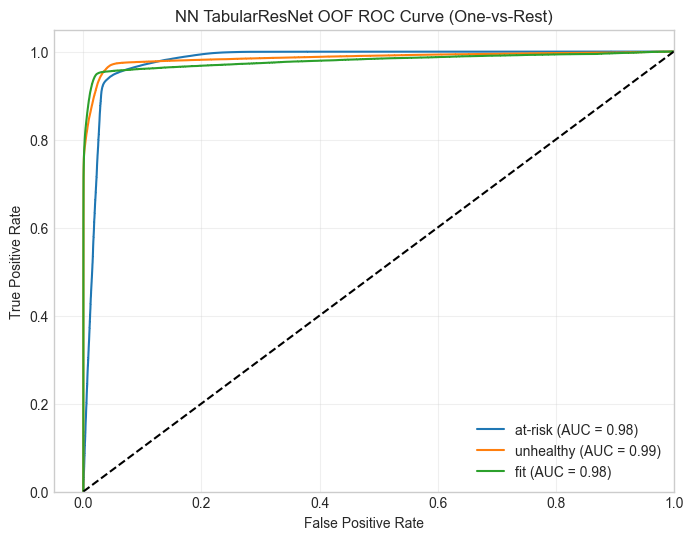

In [11]:
mviz = ModelVisualizer(model_name='NN TabularResNet')

mviz.plot_multiclass_roc_curve(
    y_true=y[filled_mask],
    y_score=oof_probs[filled_mask],
    title='NN TabularResNet OOF ROC Curve (One-vs-Rest)'
)

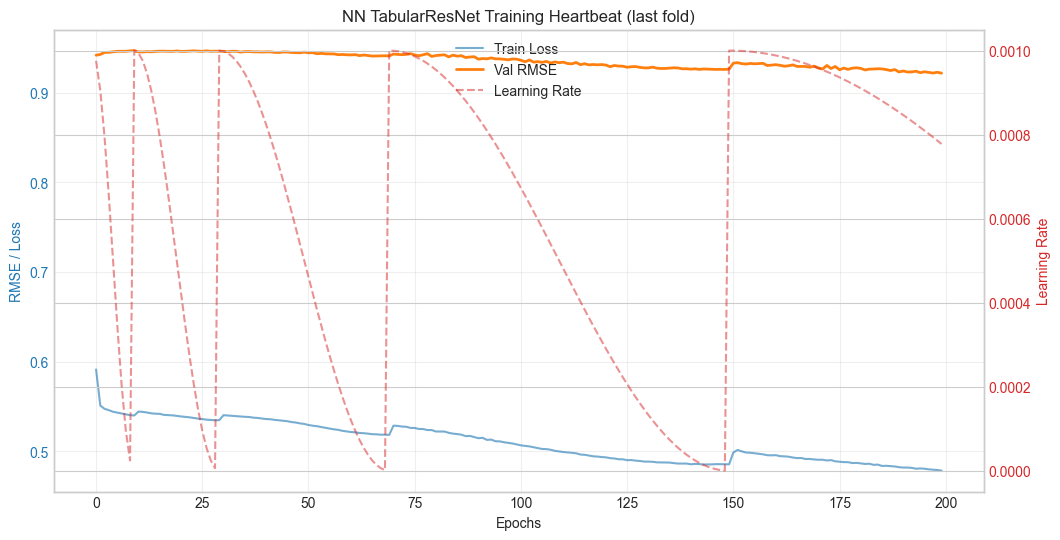

In [12]:
# Rename key to match ModelVisualizer's expected 'val_rmse' slot
# (ModelVisualizer was built for regression; we re-use it with our metric)
heartbeat_history = {
    'train_loss': history['train_loss'],
    'val_rmse':   history['val_bal_acc'],   # display as validation metric
    'lrs':        history['lrs'],
}
mviz.plot_training_heartbeat(heartbeat_history, title_suffix='(last fold)')

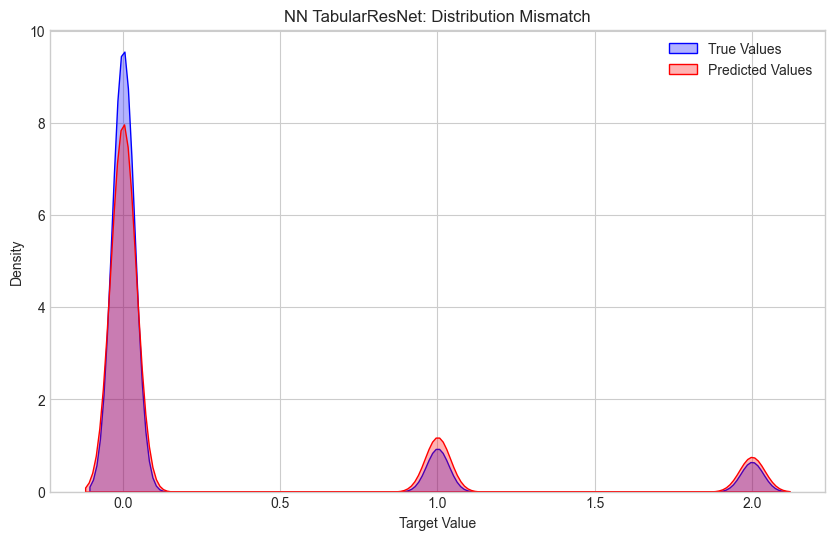

In [13]:
# Distribution of OOF predicted class vs true class (competition rows only)
mviz.plot_distribution_mismatch(y_true=y[filled_mask], y_preds=oof_preds[filled_mask])

Normalized confusion matrix


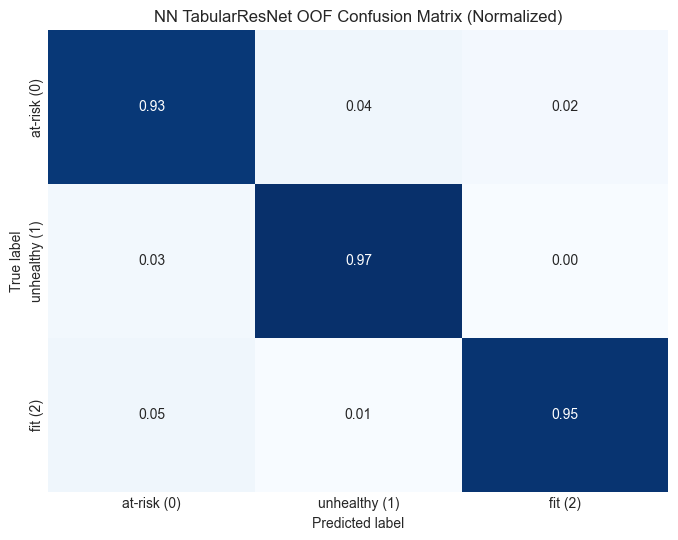

In [14]:
mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=oof_preds[filled_mask],
    classes=['at-risk (0)', 'unhealthy (1)', 'fit (2)'],
    normalize=True,
    title='NN TabularResNet OOF Confusion Matrix (Normalized)'
)

## Prepare Submission

The competition requires a hard predicted class label (`at-risk`, `unhealthy`, or `fit`) for each test row. We derive predictions by taking the argmax of the averaged test probabilities and mapping back to the original string labels.

In [15]:
submission_df = setup.read_dataset('submission')
target_col = [c for c in submission_df.columns if c != 'id'][0]

numeric_preds = np.argmax(test_probs, axis=1)
submission_df[target_col] = pd.Series(numeric_preds).map(inverse_target_mapping)

print('SAMPLE SUBMISSION')
print('=================')
print(submission_df.head(10))

print('\nPredicted Class Distribution:')
print(submission_df[target_col].value_counts(normalize=True).sort_index())

SAMPLE SUBMISSION
       id health_condition
0  690088        unhealthy
1  690089        unhealthy
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
5  690093              fit
6  690094          at-risk
7  690095          at-risk
8  690096          at-risk
9  690097          at-risk

Predicted Class Distribution:
health_condition
at-risk     0.807
fit         0.075
unhealthy   0.119
Name: proportion, dtype: float64


In [16]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

Out-of-fold (OOF) **probability matrices** (N&times;3) and averaged test-set **probability matrices** are saved for downstream blending and stacking.

These files are used to:
- Compare model performance using OOF Balanced Accuracy
- Analyze correlation and complementarity between models
- Serve as inputs to the blending and stacking notebooks

Each file contains raw, un-thresholded probabilities for all three classes. This is essential for weighted blending, stacking, and calibration analysis.

Column names match the convention used by the other model notebooks:
`prob_at_risk`, `prob_unhealthy`, `prob_fit`

In [17]:
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Column names match the class label mapping: at-risk=0, unhealthy=1, fit=2
prob_cols = ['prob_at_risk', 'prob_unhealthy', 'prob_fit']

# OOF probabilities — save only competition rows (original rows have no val prediction)
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)
oof_out = pd.concat([
    pd.DataFrame({'id': train_ids.values, 'target': y}),
    oof_prob_df
], axis=1)
oof_out = oof_out[filled_mask]  # drop original rows (no val predictions)
oof_out.to_csv(f'{output_dir}/nn_tabular_resnet_oof_probs.csv', index=False)

# Test probabilities
test_prob_df = pd.concat([
    pd.DataFrame({'id': test_ids.values}),
    pd.DataFrame(test_probs, columns=prob_cols)
], axis=1)
test_prob_df.to_csv(f'{output_dir}/nn_tabular_resnet_test_probs.csv', index=False)

print(f'Saved for blending/stacking:')
print(f'  {output_dir}/nn_tabular_resnet_oof_probs.csv')
print(f'  {output_dir}/nn_tabular_resnet_test_probs.csv')

Saved for blending/stacking:
  predictions/nn_tabular_resnet_oof_probs.csv
  predictions/nn_tabular_resnet_test_probs.csv
